In [334]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

In [335]:
df = pd.read_csv('HTRU_2.csv')

In [336]:
df.head()

,140.5625,55.68378214,-0.234571412,-0.699648398,3.199832776,19.11042633,7.975531794,74.24222492,0
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17897 entries, 0 to 17896
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   140.5625      17897 non-null  float64
 1   55.68378214   17897 non-null  float64
 2   -0.234571412  17897 non-null  float64
 3   -0.699648398  17897 non-null  float64
 4   3.199832776   17897 non-null  float64
 5   19.11042633   17897 non-null  float64
 6   7.975531794   17897 non-null  float64
 7   74.24222492   17897 non-null  float64
 8   0             17897 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


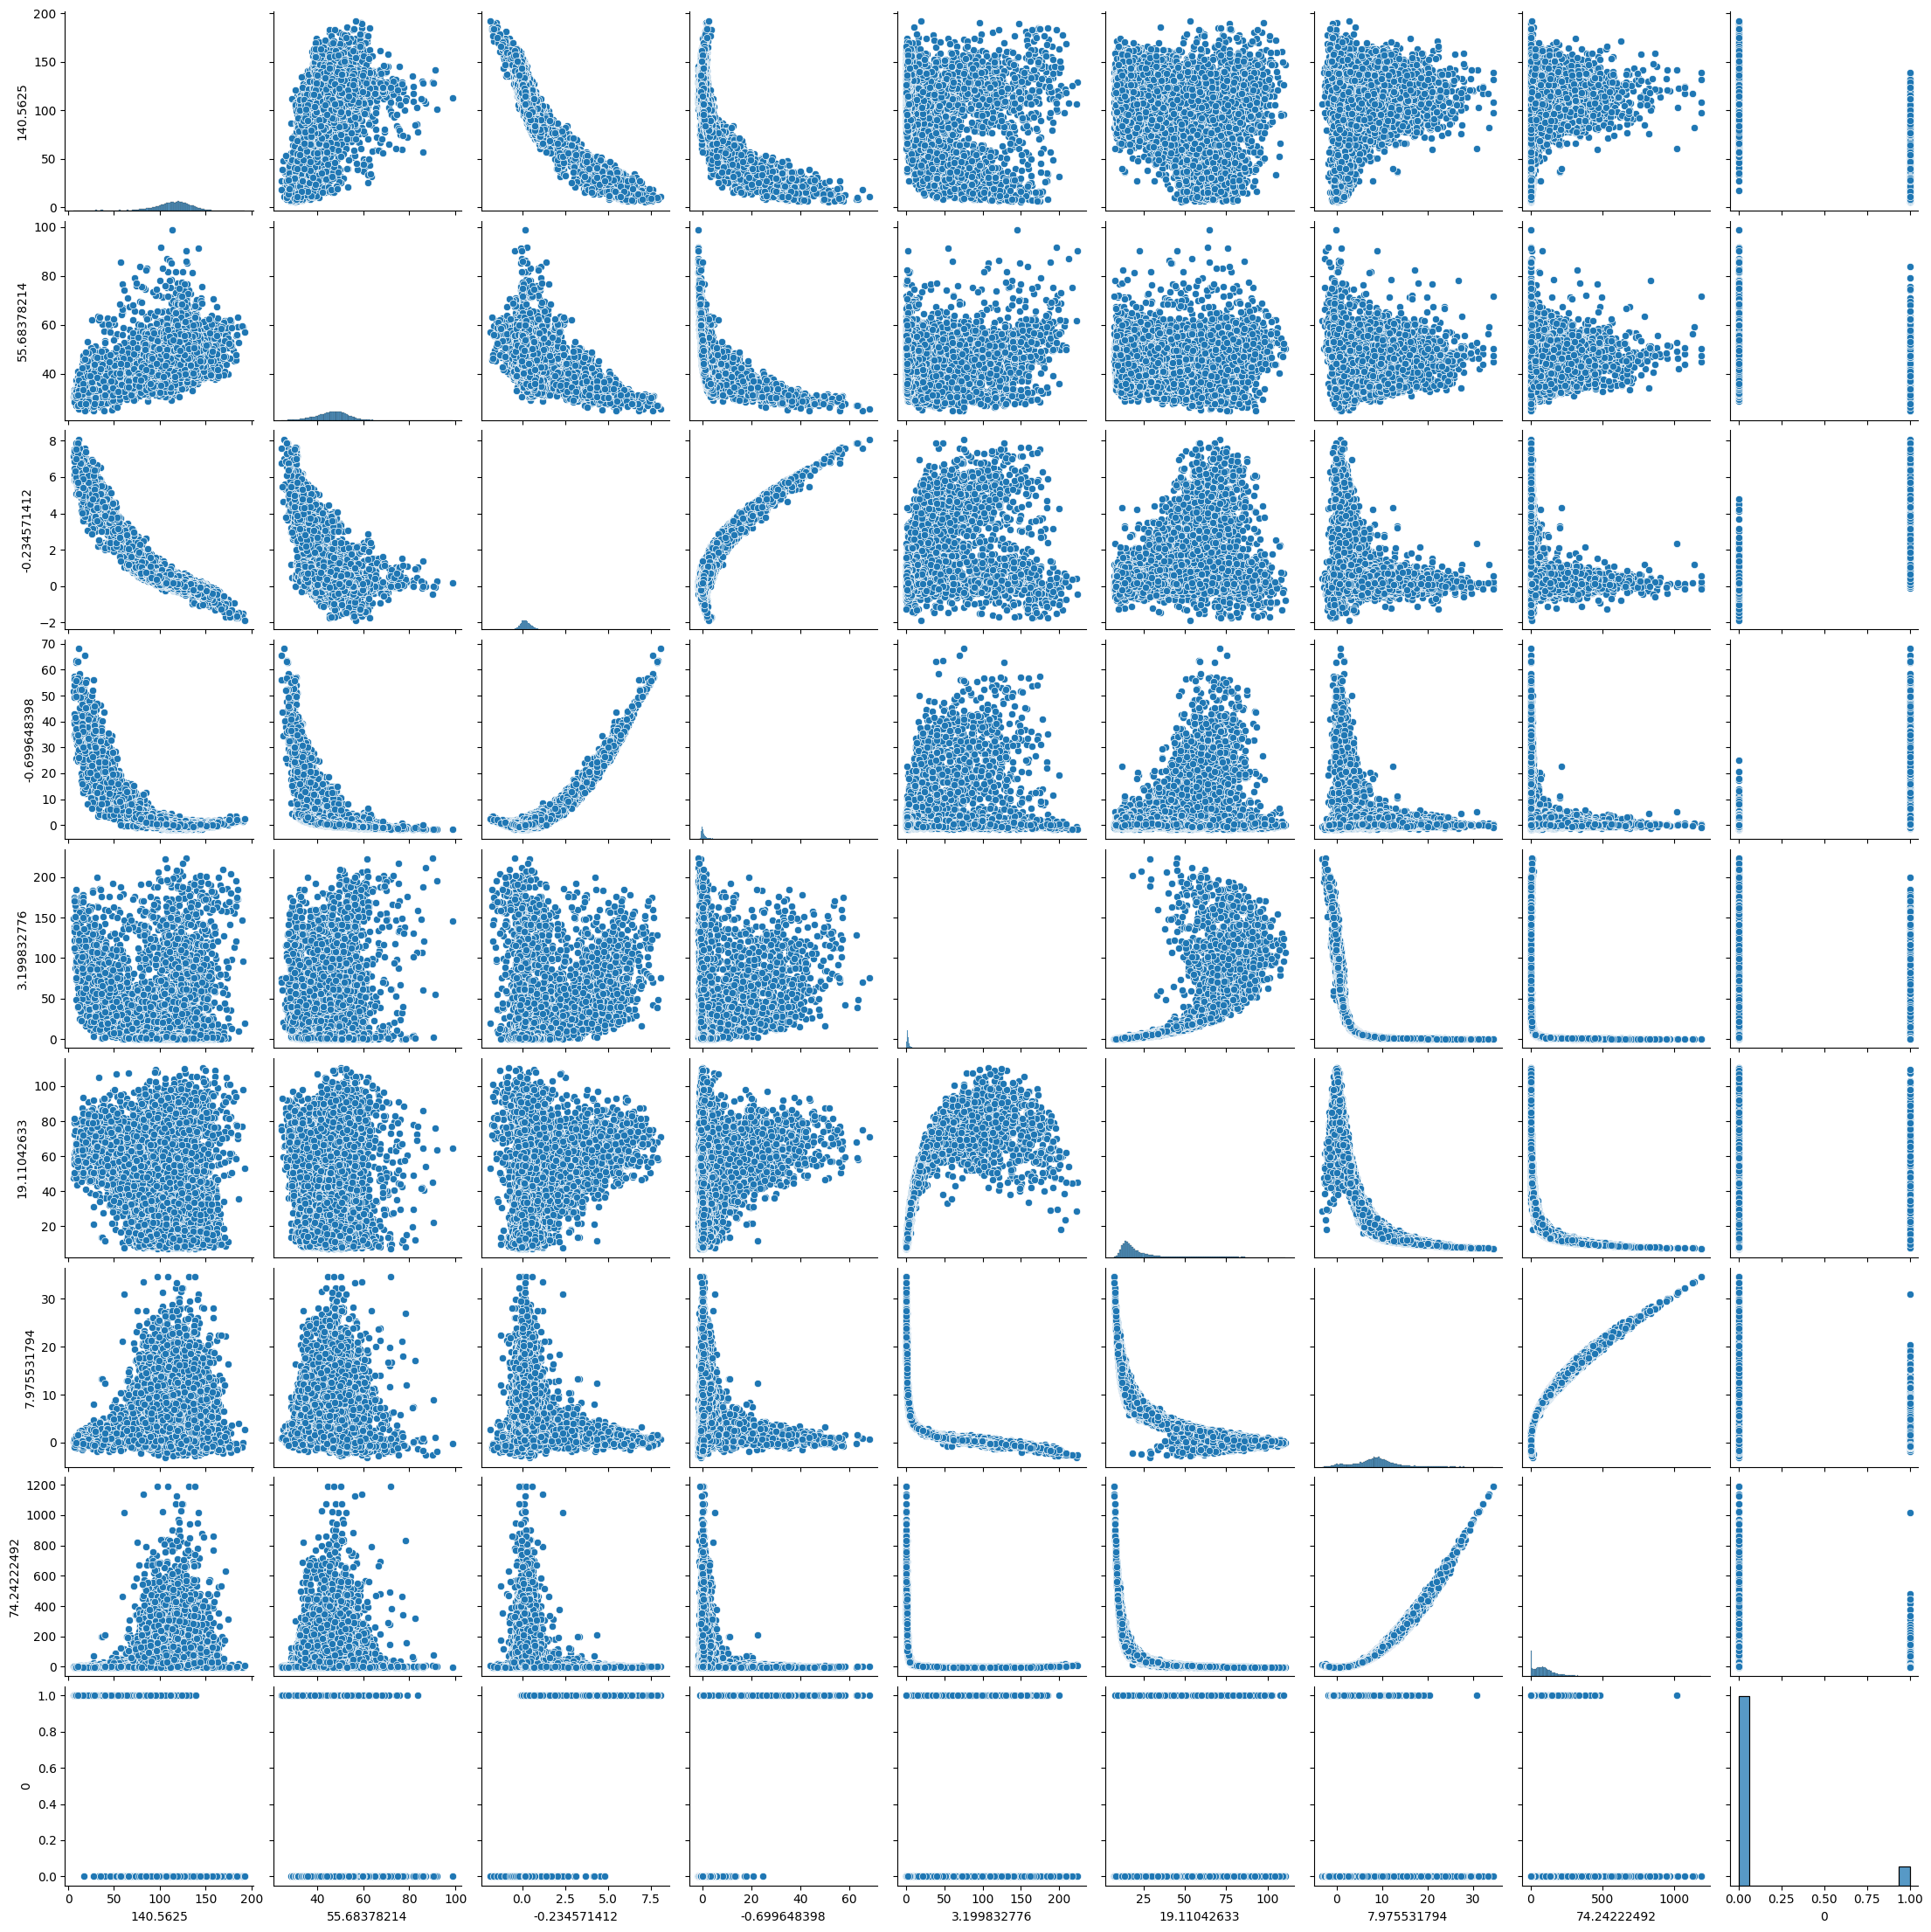

In [338]:
sns.pairplot(df)

In [339]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='0'), df['0'], random_state=42, test_size=0.2)

In [340]:
func_trf = Pipeline([('functional_trf', FunctionTransformer(func=np.log1p))])
standard_trf = Pipeline([('Standard_scaler', StandardScaler())])
preprocessor = make_column_transformer(
                                    (func_trf, ['3.199832776','19.11042633']),
                                    (standard_trf, ['140.5625',	'55.68378214',	'-0.234571412',	'-0.699648398',	'3.199832776',	'19.11042633',	'7.975531794',	'74.24222492'	])
                                   , remainder='passthrough')

In [342]:
final_pipeline = Pipeline([
                            ('preprocessor', preprocessor),
                            ('svm',SVC(kernel='poly', degree=2, class_weight={0: 0.8, 1: 1.8}, C=15)),
                           ])

In [344]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('functional_trf',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>))]),
                                                  ['3.199832776',
                                                   '19.11042633']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('Standard_scaler',
                                                                   StandardScaler())]),
                                                  ['140.5625', '55.68378214',
                                                   '-0.234571412',
                                                   '-0.699648398',
                                                   '3.199832776', '19.11042633',
                                                   '7.975531794',
                                                   '74.24222492'])])),
                ('svm',
                 SVC(C=15, class_weight={0: 0.8, 1: 1.8}, degree=2,
                     kernel='poly'))])

In [345]:
y_pred = final_pipeline.predict(X_test)

In [346]:
accuracy_score(y_test, y_pred)

0.9843575418994414

In [347]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99      3259\n           1       0.93      0.89      0.91       321\n\n    accuracy                           0.98      3580\n   macro avg       0.96      0.94      0.95      3580\nweighted avg       0.98      0.98      0.98      3580\n'

In [348]:
confusion_matrix(y_test, y_pred)

array([[3239,   20],
       [  36,  285]])